# Làm sạch và Khám phá Dữ liệu Chất lượng Không khí TP.HCM

## 0. Import Thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Thông tin tổng quan về dữ liệu

In [2]:
# Đọc dữ liệu
df = pd.read_csv('../data/raw/Air Quality Ho Chi Minh City.csv')
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

print("=== DATA TYPES ===")
display(df.dtypes)

print("=== 5 DÒNG ĐẦU TIÊN ===")
display(df.head())
print("=== 5 DÒNG CUỐI CÙNG ===")
display(df.tail())

print("=== THỐNG KÊ DỮ LIỆU ĐỊNH LƯỢNG ===")
display(df.describe())

print("=== DỮ LIỆU ĐỊNH TÍNH ===")
print(f"Cột 'date': {df['date'].nunique()} giá trị duy nhất")
print(f"Cột 'Station_No': {df['Station_No'].nunique()} trạm: {sorted(df['Station_No'].unique())}")
df.describe(include='object')

print("=== INFO ===")
df.info()

Số dòng: 52548, Số cột: 10
=== DATA TYPES ===


date            object
Station_No       int64
TSP            float64
PM2.5          float64
O3             float64
CO             float64
NO2            float64
SO2            float64
Temperature    float64
Humidity       float64
dtype: object

=== 5 DÒNG ĐẦU TIÊN ===


,date,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
0,23-02-2021 21:00,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095
1,23-02-2021 22:00,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529
2,23-02-2021 23:00,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000
3,24-02-2021 00:00,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000
4,24-02-2021 01:00,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333


=== 5 DÒNG CUỐI CÙNG ===


,date,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
52543,21-06-2022 13:00,6,21.526667,10.201667,100.080283,1007.907000,73.962600,146.720000,33.496667,60.470000
52544,21-06-2022 14:00,6,26.590000,11.250000,119.612133,1262.319000,96.609333,181.216667,33.026667,62.556667
52545,21-06-2022 15:00,6,27.606667,11.355000,119.448550,1457.330000,100.310600,212.220000,33.106667,62.175000
52546,21-06-2022 16:00,6,37.433333,15.048333,125.730150,2125.257000,128.383767,350.643333,31.406667,70.605000
52547,21-06-2022 17:00,6,27.810811,12.256757,123.085405,2180.187568,135.707459,357.594595,29.645946,75.578378


=== THỐNG KÊ DỮ LIỆU ĐỊNH LƯỢNG ===


,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
count,52548.000000,52488.000000,52548.000000,41938.000000,43483.000000,46882.000000,41542.000000,48111.000000,48116.000000
mean,3.536062,43.550369,21.126031,94.229522,993.923726,96.444586,224.611910,27.812098,63.559275
std,1.695122,35.513882,14.229703,37.535105,615.692946,71.569328,114.412342,4.291604,25.718395
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.620000,18.491667,11.320000
25%,2.000000,24.638333,12.520000,71.667044,699.432450,54.076133,140.606667,25.858333,56.558333
50%,4.000000,38.775000,17.475000,90.232567,789.555800,78.855800,193.880000,28.083333,70.615000
75%,5.000000,57.097115,25.636667,112.669312,1112.575000,113.672800,286.016667,30.680000,82.355000
max,6.000000,938.198333,403.688333,377.288600,21092.570770,461.090000,699.976667,42.808333,99.283333


=== DỮ LIỆU ĐỊNH TÍNH ===
Cột 'date': 10452 giá trị duy nhất
Cột 'Station_No': 6 trạm: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52548 entries, 0 to 52547
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         52548 non-null  object 
 1   Station_No   52548 non-null  int64  
 2   TSP          52488 non-null  float64
 3   PM2.5        52548 non-null  float64
 4   O3           41938 non-null  float64
 5   CO           43483 non-null  float64
 6   NO2          46882 non-null  float64
 7   SO2          41542 non-null  float64
 8   Temperature  48111 non-null  float64
 9   Humidity     48116 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 4.0+ MB


## 2. Kiểm tra Missing Data và Chiến lược xử lý

### 2.1 Kiểm tra tính liên tục của dữ liệu và tổng quan Missing Data

Vì đây là dữ liệu time series đo theo giờ, trước khi xử lý missing cần kiểm tra:
1. **Tính liên tục**: Có giờ nào hoàn toàn không tồn tại trong dataset không?
2. **Missing values**: Trong các hàng đã có, cột nào đang bị thiếu giá trị? $\newline$
Hai loại "thiếu" này cần được phân biệt rõ:
- **Thiếu hàng**: Giờ không tồn tại trong DataFrame → `isnull()` không thể phát hiện
- **Thiếu giá trị**: Hàng có trong DataFrame nhưng giá trị cột là NaN

In [3]:
# [1] Parse datetime và sắp xếp theo trạm + thời gian
df['datetime'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df = df.sort_values(['Station_No', 'datetime']).reset_index(drop=True)
numeric_cols = ['TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity']
print(f"Tổng số bản ghi hiện có: {len(df)}")
print(f"Thời gian bắt đầu sớm nhất: {df['datetime'].min()}")
print(f"Thời gian kết thúc muộn nhất: {df['datetime'].max()}")
print(f"Số trạm: {df['Station_No'].nunique()}")

Tổng số bản ghi hiện có: 52548
Thời gian bắt đầu sớm nhất: 2021-02-23 21:00:00
Thời gian kết thúc muộn nhất: 2022-06-21 17:00:00
Số trạm: 6


In [4]:
# [2] Kiểm tra tính liên tục: tìm các giờ bị thiếu hoàn toàn trong mỗi trạm
print("=" * 70)
print("KIỂM TRA TÍNH LIÊN TỤC CỦA DỮ LIỆU")
print("=" * 70)

total_missing_hours = 0
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station].copy()
    
    # Tạo timeline đầy đủ từ min đến max của trạm
    full_range = pd.date_range(
        start=station_df['datetime'].min(),
        end=station_df['datetime'].max(),
        freq='h'
    )
    
    # Tìm các giờ có trong timeline đầy đủ nhưng không có trong data
    existing_times = set(station_df['datetime'])
    missing_hours = sorted(set(full_range) - existing_times)
    
    expected = len(full_range)
    actual = len(station_df)
    n_missing = len(missing_hours)
    total_missing_hours += n_missing
    
    print(f"\nTrạm {station}:")
    print(f"  Khoảng thời gian: {station_df['datetime'].min()} → {station_df['datetime'].max()}")
    print(f"  Số giờ kỳ vọng: {expected}")
    print(f"  Số giờ thực có: {actual}")
    print(f"  Số giờ thiếu hoàn toàn: {n_missing} ({n_missing/expected*100:.1f}%)")
    
    if n_missing > 0 and n_missing <= 10:
        print(f"  Chi tiết giờ thiếu: {[str(h) for h in missing_hours[:10]]}")
    elif n_missing > 10:
        print(f"  10 giờ thiếu đầu tiên: {[str(h) for h in missing_hours[:10]]}")
print(f"\nTổng số giờ thiếu hoàn toàn trên tất cả trạm: {total_missing_hours}")

KIỂM TRA TÍNH LIÊN TỤC CỦA DỮ LIỆU

Trạm 1:
  Khoảng thời gian: 2021-02-23 21:00:00 → 2022-06-21 17:00:00
  Số giờ kỳ vọng: 11589
  Số giờ thực có: 7892
  Số giờ thiếu hoàn toàn: 3697 (31.9%)
  10 giờ thiếu đầu tiên: ['2021-02-25 09:00:00', '2021-02-25 10:00:00', '2021-02-25 12:00:00', '2021-02-25 13:00:00', '2021-02-25 14:00:00', '2021-02-25 15:00:00', '2021-02-25 16:00:00', '2021-02-25 17:00:00', '2021-02-25 18:00:00', '2021-02-25 19:00:00']

Trạm 2:
  Khoảng thời gian: 2021-02-23 21:00:00 → 2022-06-21 17:00:00
  Số giờ kỳ vọng: 11589
  Số giờ thực có: 9357
  Số giờ thiếu hoàn toàn: 2232 (19.3%)
  10 giờ thiếu đầu tiên: ['2021-02-25 09:00:00', '2021-02-25 10:00:00', '2021-02-25 12:00:00', '2021-02-25 13:00:00', '2021-02-25 14:00:00', '2021-02-25 15:00:00', '2021-02-25 16:00:00', '2021-02-25 17:00:00', '2021-02-25 18:00:00', '2021-02-25 19:00:00']

Trạm 3:
  Khoảng thời gian: 2021-02-23 21:00:00 → 2022-06-21 17:00:00
  Số giờ kỳ vọng: 11589
  Số giờ thực có: 8418
  Số giờ thiếu hoàn t

In [5]:
# [3] Kiểm tra missing values trong dữ liệu HIỆN CÓ (các hàng đã tồn tại)
print("=" * 70)
print("MISSING VALUES TRONG DỮ LIỆU HIỆN CÓ")
print("=" * 70)
# Tổng quan missing theo cột
missing = df[numeric_cols].isnull().sum()
missing_pct = (df[numeric_cols].isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("\n--- Tổng quan Missing (toàn bộ dataset) ---")
print(missing_df if len(missing_df) > 0 else "Không có missing data")
# Missing chi tiết theo trạm × cột
print("\n--- Missing theo Trạm x Cột ---")
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station]
    station_missing = station_df[numeric_cols].isnull().sum()
    station_missing = station_missing[station_missing > 0]
    if len(station_missing) > 0:
        print(f"\n  Trạm {station} ({len(station_df)} bản ghi):")
        for col, count in station_missing.items():
            print(f"    {col}: {count} missing ({count/len(station_df)*100:.2f}%)")

MISSING VALUES TRONG DỮ LIỆU HIỆN CÓ

--- Tổng quan Missing (toàn bộ dataset) ---
             Missing Count  Missing %
SO2                  11006      20.94
O3                   10610      20.19
CO                    9065      17.25
NO2                   5666      10.78
Temperature           4437       8.44
Humidity              4432       8.43
TSP                     60       0.11

--- Missing theo Trạm x Cột ---

  Trạm 1 (7892 bản ghi):
    TSP: 60 missing (0.76%)
    O3: 5665 missing (71.78%)
    CO: 65 missing (0.82%)
    NO2: 5665 missing (71.78%)
    SO2: 5709 missing (72.34%)

  Trạm 2 (9357 bản ghi):
    CO: 8999 missing (96.17%)
    SO2: 9 missing (0.10%)

  Trạm 3 (8418 bản ghi):
    O3: 1 missing (0.01%)
    CO: 1 missing (0.01%)
    SO2: 28 missing (0.33%)

  Trạm 4 (9951 bản ghi):
    O3: 36 missing (0.36%)
    SO2: 12 missing (0.12%)

  Trạm 5 (7431 bản ghi):
    O3: 4908 missing (66.05%)
    NO2: 1 missing (0.01%)
    SO2: 4945 missing (66.55%)
    Temperature: 4437 mi

In [6]:
# [4] Phân tích các chuỗi missing liên tiếp (gap analysis)
print("=" * 70)
print("PHÂN TÍCH CHUỖI MISSING LIÊN TIẾP")
print("=" * 70)
results = []
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station].copy()
    
    for col in numeric_cols:
        is_missing = station_df[col].isnull()
        
        if is_missing.sum() == 0:
            continue
        
        groups = (~is_missing).cumsum()
        missing_groups = station_df[is_missing].groupby(groups)
        
        for group_id, group_data in missing_groups:
            streak_len = len(group_data)
            start_time = group_data['datetime'].iloc[0]
            end_time = group_data['datetime'].iloc[-1]
            duration_hours = (end_time - start_time).total_seconds() / 3600 + 1
            
            results.append({
                'Station': station,
                'Column': col,
                'Streak_Length': streak_len,
                'Duration_Hours': duration_hours,
                'Start': start_time,
                'End': end_time
            })

streak_df = pd.DataFrame(results)

if len(streak_df) > 0:
    print(f"\nTổng số chuỗi missing: {len(streak_df)}")
    print(f"\nThống kê Duration_Hours:")
    print(streak_df['Duration_Hours'].describe().round(1))
    
    # Phân loại sơ bộ
    short_gaps = streak_df[streak_df['Duration_Hours'] <= 100]
    long_gaps = streak_df[streak_df['Duration_Hours'] > 100]
    
    print(f"\n--- Gap ngắn (≤ 100h): {len(short_gaps)} chuỗi ---")
    if len(short_gaps) > 0:
        print(f"  Min duration: {short_gaps['Duration_Hours'].min():.0f}h")
        print(f"  Max duration: {short_gaps['Duration_Hours'].max():.0f}h")
        print(f"  Tổng missing rows: {short_gaps['Streak_Length'].sum()}")
    
    print(f"\n--- Gap dài (> 100h): {len(long_gaps)} chuỗi ---")
    if len(long_gaps) > 0:
        print(long_gaps[['Station', 'Column', 'Streak_Length', 'Duration_Hours', 'Start', 'End']]
              .sort_values('Duration_Hours', ascending=False).to_string(index=False))
else:
    print("Không có missing data")

PHÂN TÍCH CHUỖI MISSING LIÊN TIẾP

Tổng số chuỗi missing: 264

Thống kê Duration_Hours:
count      264.0
mean       198.6
std       1133.0
min          1.0
25%          1.0
50%          1.0
75%          2.0
max      10684.0
Name: Duration_Hours, dtype: float64

--- Gap ngắn (≤ 100h): 252 chuỗi ---
  Min duration: 1h
  Max duration: 72h
  Tổng missing rows: 637

--- Gap dài (> 100h): 12 chuỗi ---
 Station      Column  Streak_Length  Duration_Hours               Start                 End
       2          CO           8997         10684.0 2021-04-02 14:00:00 2022-06-21 17:00:00
       1          O3           5665          6122.0 2021-10-09 16:00:00 2022-06-21 17:00:00
       1         NO2           5665          6122.0 2021-10-09 16:00:00 2022-06-21 17:00:00
       5          O3           4908          6075.0 2021-10-11 15:00:00 2022-06-21 17:00:00
       1         SO2           5597          6050.0 2021-10-12 16:00:00 2022-06-21 17:00:00
       5         SO2           4907          6027

**Nhận xét:**
1. **Tính liên tục**: Dữ liệu không liên tục — có nhiều giờ hoàn toàn không tồn tại trong dataset. Điều này nghĩa là phân tích gap dựa trên `Streak_Length` (đếm số hàng) sẽ không chính xác so với `Duration_Hours` (thời gian thực tế), vì các hàng thiếu làm cho gap trông ngắn hơn thực tế.
2. **Missing data có 2 loại rõ ràng** (phân phối bimodal):
   - **Gap nhỏ** (vài chục giờ): Missing rải rác, nhiễu sensor → có thể xử lý bằng interpolation
   - **Gap lớn** (hàng trăm đến nghìn giờ): Sensor hỏng/ngừng đo → không nên interpolation
3. Cần **reindex** về complete hourly timeline trước khi xử lý missing, để đảm bảo mọi khoảng trống đều được phát hiện đầy đủ và `Streak_Length` khớp với `Duration_Hours`.

### 2.2 Reindex về complete hourly timeline và gắn Quality Flag

Bước này thực hiện 2 việc quan trọng:
1. **Reindex**: Tạo timeline hourly liên tục cho mỗi trạm, thêm hàng NaN cho các giờ bị thiếu
2. **Gắn Quality Flag**: Đánh dấu nguồn gốc của mỗi giá trị trước impute (sau khi impute sẽ không phân biệt được) $\newline$
**Hệ thống flag trước imputation:**
- `0`: Giá trị gốc — đo được từ sensor
- `1`: Missing gốc — hàng có trong raw data nhưng giá trị NaN (sensor lỗi tạm thời)
- `2`: Missing do reindex — hàng mới thêm (không tồn tại trong raw data, sensor không ghi dữ liệu)

In [7]:
# [1] Reindex về complete hourly timeline + gắn quality flag
# Lưu lại danh sách datetime gốc của mỗi trạm (trước reindex)
original_datetimes = {}
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station]
    original_datetimes[station] = set(station_df['datetime'])

# Thực hiện reindex
all_stations = []
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station].copy()
    station_df = station_df.set_index('datetime')
    
    # Tạo timeline đầy đủ
    full_range = pd.date_range(
        start=station_df.index.min(),
        end=station_df.index.max(),
        freq='h'
    )
    
    # Reindex — các giờ thiếu sẽ có giá trị NaN ở tất cả cột
    station_df = station_df.reindex(full_range)
    
    # Gắn lại Station_No (bị NaN ở hàng mới)
    station_df['Station_No'] = station
    
    # Reset index
    station_df = station_df.reset_index().rename(columns={'index': 'datetime'})
    
    all_stations.append(station_df)

df = pd.concat(all_stations, ignore_index=True)

for col in numeric_cols:
    flag_col = f'{col}_flag'
    df[flag_col] = 0  # Mặc định measured
    
    # Tạo mask: giá trị NaN
    is_nan = df[col].isna()
    
    # Tạo mask: hàng gốc (datetime có trong original_datetimes)
    is_original = df.apply(
        lambda row: row['datetime'] in original_datetimes[row['Station_No']], 
        axis=1
    )
    
    # Flag 1: hàng gốc + NaN
    df.loc[is_nan & is_original, flag_col] = 1
    
    # Flag 2: hàng mới (không phải gốc) + NaN
    df.loc[is_nan & ~is_original, flag_col] = 2

print("=== SAU KHI REINDEX ===")
print(f"Tổng bản ghi: {len(df)}")
print(f"\nMissing values sau reindex:")
for col in numeric_cols:
    flag_col = f'{col}_flag'
    n_flag0 = (df[flag_col] == 0).sum()
    n_flag1 = (df[flag_col] == 1).sum()
    n_flag2 = (df[flag_col] == 2).sum()
    total_missing = n_flag1 + n_flag2
    print(f"  {col}: {total_missing} missing "
          f"(flag1={n_flag1} NaN gốc, flag2={n_flag2} do reindex)")

=== SAU KHI REINDEX ===
Tổng bản ghi: 69515

Missing values sau reindex:
  TSP: 17027 missing (flag1=60 NaN gốc, flag2=16967 do reindex)
  PM2.5: 16967 missing (flag1=0 NaN gốc, flag2=16967 do reindex)
  O3: 27577 missing (flag1=10610 NaN gốc, flag2=16967 do reindex)
  CO: 26032 missing (flag1=9065 NaN gốc, flag2=16967 do reindex)
  NO2: 22633 missing (flag1=5666 NaN gốc, flag2=16967 do reindex)
  SO2: 27973 missing (flag1=11006 NaN gốc, flag2=16967 do reindex)
  Temperature: 21404 missing (flag1=4437 NaN gốc, flag2=16967 do reindex)
  Humidity: 21399 missing (flag1=4432 NaN gốc, flag2=16967 do reindex)


In [8]:
# [2] Verify: kiểm tra timeline đã liên tục chưa
print("=== VERIFY TÍNH LIÊN TỤC SAU REINDEX ===\n")
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station].copy()
    
    # Kiểm tra khoảng cách giữa các hàng liên tiếp
    time_diffs = station_df['datetime'].diff().dropna()
    non_hourly = time_diffs[time_diffs != pd.Timedelta(hours=1)]
    
    if len(non_hourly) == 0:
        print(f"Trạm {station}: Timeline liên tục ({len(station_df)} bản ghi)")
    else:
        print(f"Trạm {station}: Còn {len(non_hourly)} khoảng không liên tục!")
        
# So sánh trước/sau reindex
print(f"\n--- So sánh ---")
total_original = sum(len(v) for v in original_datetimes.values())
print(f"Tổng bản ghi trước reindex: {total_original}")
print(f"Tổng bản ghi sau reindex:   {len(df)}")
print(f"Số hàng mới thêm:           {len(df) - total_original}")

=== VERIFY TÍNH LIÊN TỤC SAU REINDEX ===

Trạm 1: Timeline liên tục (11589 bản ghi)
Trạm 2: Timeline liên tục (11589 bản ghi)
Trạm 3: Timeline liên tục (11589 bản ghi)
Trạm 4: Timeline liên tục (11589 bản ghi)
Trạm 5: Timeline liên tục (11589 bản ghi)
Trạm 6: Timeline liên tục (11570 bản ghi)

--- So sánh ---
Tổng bản ghi trước reindex: 52548
Tổng bản ghi sau reindex:   69515
Số hàng mới thêm:           16967


In [9]:
# [3] Phân tích gap sau reindex
print("=== PHÂN TÍCH GAP SAU REINDEX ===\n")
results_after = []
for station in sorted(df['Station_No'].unique()):
    station_df = df[df['Station_No'] == station].copy()
    
    for col in numeric_cols:
        is_missing = station_df[col].isnull()
        
        if is_missing.sum() == 0:
            continue
        
        groups = (~is_missing).cumsum()
        missing_groups = station_df[is_missing].groupby(groups)
        
        for group_id, group_data in missing_groups:
            streak_len = len(group_data)
            start_time = group_data['datetime'].iloc[0]
            end_time = group_data['datetime'].iloc[-1]
            duration_hours = (end_time - start_time).total_seconds() / 3600 + 1
            
            results_after.append({
                'Station': station,
                'Column': col,
                'Streak_Length': streak_len,
                'Duration_Hours': duration_hours,
                'Start': start_time,
                'End': end_time
            })

streak_df_after = pd.DataFrame(results_after)
# Verify: Streak_Length == Duration_Hours
if len(streak_df_after) > 0:
    mismatch = streak_df_after[streak_df_after['Streak_Length'] != streak_df_after['Duration_Hours']]
    if len(mismatch) == 0:
        print("Streak_Length = Duration_Hours cho tất cả các gap (timeline liên tục)")
    else:
        print(f"Còn {len(mismatch)} gap có Streak_Length ≠ Duration_Hours")
    
    print(f"\nTổng số gap: {len(streak_df_after)}")
    print(f"\nPhân bố Duration_Hours:")
    print(streak_df_after['Duration_Hours'].describe().round(1))

=== PHÂN TÍCH GAP SAU REINDEX ===

Streak_Length = Duration_Hours cho tất cả các gap (timeline liên tục)

Tổng số gap: 3791

Phân bố Duration_Hours:
count     3791.0
mean        47.7
std        342.9
min          1.0
25%          1.0
50%          6.0
75%         22.5
max      10684.0
Name: Duration_Hours, dtype: float64


**Nhận xét:**
1. Sau khi reindex, timeline đã **hoàn toàn liên tục** cho mỗi trạm, mỗi giờ đều có đúng 1 hàng.
2. `Streak_Length` và `Duration_Hours` giờ đã **khớp nhau**, xác nhận reindex chính xác. Từ đây, số hàng NaN liên tiếp = số giờ thực tế bị missing.
3. Quality flag đã được gắn thành công:
   - **Flag 0**: Giá trị thực đo từ sensor
   - **Flag 1**: Hàng gốc có trong raw data nhưng giá trị NaN (sensor lỗi tạm thời)
   - **Flag 2**: Hàng mới thêm do reindex (sensor không ghi dữ liệu)

### 2.3 Thực hiện xử lý Missing Data

In [10]:
# [1] Tính toán gap length cho tất cả biến (dùng cho phân tích phân phối)
gap_records = []
for station in sorted(df['Station_No'].unique()):
    sdf = df[df['Station_No'] == station].copy().sort_values('datetime').reset_index(drop=True)
    for col in numeric_cols:
        is_missing = sdf[col].isnull()
        if is_missing.sum() == 0:
            continue
        groups = (~is_missing).cumsum()
        for gid, gdata in sdf[is_missing].groupby(groups):
            gap_records.append({
                'Column'  : col,
                'Station' : station,
                'Duration': len(gdata),           # sau reindex: Duration = Duration_Hours
                'Start'   : gdata['datetime'].iloc[0],
                'End'     : gdata['datetime'].iloc[-1],
            })

gap_df = pd.DataFrame(gap_records)
print(f"Tổng số gap: {len(gap_df)}")
print(f"Phân bố Duration (toàn bộ):")
print(gap_df['Duration'].describe().round(1))


Tổng số gap: 3791
Phân bố Duration (toàn bộ):
count     3791.0
mean        47.7
std        342.9
min          1.0
25%          1.0
50%          6.0
75%         22.5
max      10684.0
Name: Duration, dtype: float64


In [11]:
# Phân tích vị trí percentile của ngưỡng 6h và 72h trong phân phối gap
print("=" * 70)
print("CƠ SỞ THỐNG KÊ CHO NGƯỠNG")
print("=" * 70)

for col in numeric_cols:
    durations = gap_df[gap_df['Column'] == col]['Duration']
    total = len(durations)
    
    n_tier1 = (durations <= 6).sum()
    n_tier2 = ((durations > 6) & (durations <= 72)).sum()
    n_tier3 = (durations > 72).sum()
    
    pct_6h = (durations <= 6).sum() / total * 100
    pct_72h = (durations <= 72).sum() / total * 100
    
    print(f"{col:<12}: <=6h: {n_tier1:>4} gaps ({pct_6h:>5.1f}%)  |  "
          f"7-72h: {n_tier2:>4} gaps ({pct_72h - pct_6h:>5.1f}%)  |  "
          f">72h: {n_tier3:>4} gaps ({100 - pct_72h:>5.1f}%)")

# Tổng hợp
all_d = gap_df['Duration']
print(f"\n{'TỔNG':<12}: <=6h: {(all_d <= 6).sum():>4} gaps ({(all_d <= 6).mean()*100:>5.1f}%)  |  "
      f"7-72h: {((all_d > 6) & (all_d <= 72)).sum():>4} gaps  ({((all_d > 6) & (all_d <= 72)).mean()*100:>5.1f}%)  |  "
      f">72h: {(all_d > 72).sum():>4} gaps ({(all_d > 72).mean()*100:>5.1f}%)")

print(f"\nNgưỡng 6h nằm ở percentile {(all_d <= 6).mean()*100:.1f} của phân phối gap")
print(f"Ngưỡng 72h nằm ở percentile {(all_d <= 72).mean()*100:.1f} của phân phối gap")


CƠ SỞ THỐNG KÊ CHO NGƯỠNG
TSP         : <=6h:  222 gaps ( 47.3%)  |  7-72h:  199 gaps ( 42.4%)  |  >72h:   48 gaps ( 10.2%)
PM2.5       : <=6h:  223 gaps ( 47.6%)  |  7-72h:  197 gaps ( 42.1%)  |  >72h:   48 gaps ( 10.3%)
O3          : <=6h:  214 gaps ( 48.2%)  |  7-72h:  186 gaps ( 41.9%)  |  >72h:   44 gaps (  9.9%)
CO          : <=6h:  209 gaps ( 50.4%)  |  7-72h:  163 gaps ( 39.3%)  |  >72h:   43 gaps ( 10.4%)
NO2         : <=6h:  217 gaps ( 48.0%)  |  7-72h:  187 gaps ( 41.4%)  |  >72h:   48 gaps ( 10.6%)
SO2         : <=6h:  400 gaps ( 63.4%)  |  7-72h:  186 gaps ( 29.5%)  |  >72h:   45 gaps (  7.1%)
Temperature : <=6h:  216 gaps ( 47.4%)  |  7-72h:  194 gaps ( 42.5%)  |  >72h:   46 gaps ( 10.1%)
Humidity    : <=6h:  216 gaps ( 47.4%)  |  7-72h:  194 gaps ( 42.5%)  |  >72h:   46 gaps ( 10.1%)

TỔNG        : <=6h: 1917 gaps ( 50.6%)  |  7-72h: 1506 gaps  ( 39.7%)  |  >72h:  368 gaps (  9.7%)

Ngưỡng 6h nằm ở percentile 50.6 của phân phối gap
Ngưỡng 72h nằm ở percentile 90.3 của ph

**Cơ sở chọn ngưỡng 6h và 72h:**
- **Ngưỡng 6h** nằm ở **percentile ~50.6** của phân phối gap — phủ hơn một nửa tổng số gap. Về mặt vật lý, 6h là khoảng biến thiên cục bộ gần tuyến tính trong chu kỳ ngày/đêm — chưa qua đỉnh hoặc đáy ngày/đêm.
- **Ngưỡng 72h** nằm ở **percentile ~90.3** — cho phép impute ~90% tổng gap. 72h = 3 chu kỳ ngày/đêm, là giới hạn để seasonal mean (+/- 3 ngày window) còn đáng tin cậy, vì điều kiện khí tượng trong 3 ngày còn tương đối ổn định.
- Gap **> 72h** (~9.7% còn lại) quá dài để bất kỳ phương pháp imputation nào cho kết quả tin cậy → giữ NaN.

Dựa trên kết quả phân tích ở 2.1 và 2.2, chiến lược được thiết kế theo nguyên tắc **"impute ít nhất có thể, minh bạch nhất có thể"**:
**Chiến lược imputation:**
| Loại gap | Phương pháp | Lý do |
|---|---|---|
| 1–6h | `linear` interpolation | Đủ ngắn để biến thiên cục bộ gần tuyến tính, chưa qua peak/trough ngày/đêm |
| 7–72h | Seasonal mean (same hour +/- 3 ngày) | Khai thác chu kỳ ngày/đêm, 3 ngày window đủ candidates, điều kiện khí tượng còn tương đối ổn định |
| > 72h | Giữ NaN, flag = `2` (not_imputed) | Quá dài, uncertainty quá cao — không method nào đáng tin cậy |
> **Lưu ý:** Sau khi imputation hoàn tất, hệ thống Quality Flag được **cập nhật lại** với ý nghĩa mới:
> - `0` = Giá trị gốc (sensor đo được)
> - `1` = Imputed (linear hoặc seasonal mean)
> - `2` = Not imputed — gap > 72h hoặc không đủ candidates (NaN được giữ nguyên)
>
> Hệ thống flag 3 cấp trước imputation (0=measured, 1=NaN gốc, 2=NaN do reindex) được thay thế bằng hệ thống 3 cấp mới tập trung vào **nguồn gốc giá trị** thay vì **nguồn gốc missing**, vì sau imputation thông tin quan trọng nhất là: giá trị nào đáng tin cậy (gốc), giá trị nào là ước lượng (imputed), và vùng nào hoàn toàn không có dữ liệu (not_imputed).

In [12]:
# [1] Hàm phân loại từng gap và thực hiện imputation theo chiến lược
THRESHOLD_LINEAR = 6       # gap <= 6h: linear interpolation
THRESHOLD_SEASONAL = 72    # gap 7–72h: seasonal mean (same-hour +- 3 ngày)

def seasonal_fill(series: pd.Series, gap_index, window_days: int = 3) -> pd.Series:
    """
    Fill missing values dựa trên trung bình giá trị cùng giờ trong cửa sổ
    window_days ngày trước và sau mỗi điểm missing.
    series phải có DatetimeIndex hourly liên tục.
    """
    filled = series.copy()
    for idx in gap_index:
        hour = idx.hour
        # Lấy các timestamp cùng giờ trong [idx - window, idx + window], loại chính idx
        window_start = idx - pd.Timedelta(days=window_days)
        window_end   = idx + pd.Timedelta(days=window_days)
        same_hour_mask = (
            (series.index >= window_start) &
            (series.index <= window_end) &
            (series.index.hour == hour) &
            (series.index != idx)
        )
        candidates = series[same_hour_mask].dropna()
        if len(candidates) >= 2:      # cần ít nhất 2 điểm để tính mean tin cậy
            filled[idx] = candidates.mean()
        # nếu không đủ candidates ==> giữ NaN (sẽ được flag = not_imputed)
    return filled

print(f"Threshold: linear <= {THRESHOLD_LINEAR}h  | seasonal <= {THRESHOLD_SEASONAL}h  | giữ NaN > {THRESHOLD_SEASONAL}h")

Threshold: linear <= 6h  | seasonal <= 72h  | giữ NaN > 72h


In [13]:
# [2] Vòng lặp imputation chính — xử lý từng trạm × từng biến
print("=" * 70)
print("THỰC HIỆN IMPUTATION")
print("=" * 70)

imputation_log = []

for station in sorted(df['Station_No'].unique()):
    sdf = df[df['Station_No'] == station].copy()
    sdf = sdf.set_index('datetime').sort_index()

    for col in numeric_cols:
        flag_col = f'{col}_flag'

        if sdf[col].isnull().sum() == 0:
            continue

        is_missing = sdf[col].isnull()
        groups = (~is_missing).cumsum()

        for gid, gdata in sdf[is_missing].groupby(groups):
            gap_len = len(gdata)
            gap_idx = gdata.index

            if gap_len <= THRESHOLD_LINEAR:
                # 1–6h — linear interpolation (chỉ fill đúng gap này)
                before = sdf[col].loc[:gap_idx[0]].last_valid_index()
                after  = sdf[col].loc[gap_idx[-1]:].first_valid_index()

                if before is not None and after is not None:
                    segment = sdf[col].loc[before:after]
                    filled_segment = segment.interpolate(method='linear')
                    sdf.loc[gap_idx, col] = filled_segment.loc[gap_idx]
                    sdf.loc[gap_idx[sdf.loc[gap_idx, col].notna()], flag_col] = 1
                    method = 'linear'
                else:
                    # Gap ở đầu/cuối series — không đủ 2 phía để interpolate
                    sdf.loc[gap_idx, flag_col] = 2
                    method = 'not_imputed (edge)'

            elif gap_len <= THRESHOLD_SEASONAL:
                # 7–72h — seasonal mean (cùng giờ +- 3 ngày)
                filled = seasonal_fill(sdf[col], gap_idx, window_days=3)
                newly_filled = gap_idx[filled[gap_idx].notna() & sdf[col][gap_idx].isna()]

                if len(newly_filled) > 0:
                    sdf.loc[newly_filled, col] = filled[newly_filled]
                    sdf.loc[newly_filled, flag_col] = 1

                # Điểm vẫn NaN sau seasonal => không đủ candidates
                still_nan = gap_idx[sdf.loc[gap_idx, col].isna()]
                if len(still_nan) > 0:
                    sdf.loc[still_nan, flag_col] = 2
                method = 'seasonal'

            else:
                # > 72h — uncertainty quá cao, không impute
                sdf.loc[gap_idx, flag_col] = 2
                method = 'not_imputed'

            imputation_log.append({
                'Station': station, 'Column': col,
                'Gap_Length': gap_len, 'Method': method,
                'Start': gap_idx[0], 'End': gap_idx[-1]
            })

    # Ghi kết quả trạm này vào df gốc
    sdf = sdf.reset_index()
    mask = df['Station_No'] == station
    for c in numeric_cols:
        df.loc[mask, c] = sdf[c].values
        df.loc[mask, f'{c}_flag'] = sdf[f'{c}_flag'].values

print("Hoàn thành imputation")
log_df = pd.DataFrame(imputation_log)
print(f"Tổng số gap đã xử lý: {len(log_df)}")

THỰC HIỆN IMPUTATION
Hoàn thành imputation
Tổng số gap đã xử lý: 3791


In [14]:
# [3] Báo cáo tổng kết imputation
print("=" * 70)
print("BÁO CÁO KẾT QUẢ IMPUTATION")
print("=" * 70)

method_summary = log_df.groupby('Method').agg(
    Số_gap=('Gap_Length', 'count'),
    Tổng_giờ=('Gap_Length', 'sum'),
    Gap_min=('Gap_Length', 'min'),
    Gap_max=('Gap_Length', 'max')
).sort_values('Tổng_giờ', ascending=False)

print("\n--- Tổng kết theo phương pháp ---")
print(method_summary.to_string())

print("\n--- Missing còn lại sau imputation (theo cột) ---")
for col in numeric_cols:
    n_flag2 = (df[f'{col}_flag'] == 2).sum()
    n_flag1 = (df[f'{col}_flag'] == 1).sum()
    n_flag0 = (df[f'{col}_flag'] == 0).sum()
    total   = len(df)
    print(f"  {col:12s}: flag0={n_flag0:6d} (gốc) | "
          f"flag1={n_flag1:5d} (imputed) | "
          f"flag2={n_flag2:6d} (not_imputed)")

print("\n--- Các station/biến có gap dài không được impute ---")
not_imputed = log_df[log_df['Method'].str.startswith('not_imputed')]
summary_ni = not_imputed.groupby(['Station', 'Column']).agg(
    Số_gap=('Gap_Length', 'count'),
    Tổng_giờ=('Gap_Length', 'sum'),
    Gap_lớn_nhất=('Gap_Length', 'max')
).sort_values('Tổng_giờ', ascending=False)
print(summary_ni.to_string())


BÁO CÁO KẾT QUẢ IMPUTATION

--- Tổng kết theo phương pháp ---
             Số_gap  Tổng_giờ  Gap_min  Gap_max
Method                                         
not_imputed     368    141865       88    10684
seasonal       1506     35352        7       72
linear         1917      3795        1        6

--- Missing còn lại sau imputation (theo cột) ---
  TSP         : flag0= 52488 (gốc) | flag1= 4979 (imputed) | flag2= 12048 (not_imputed)
  PM2.5       : flag0= 52548 (gốc) | flag1= 4931 (imputed) | flag2= 12036 (not_imputed)
  O3          : flag0= 41938 (gốc) | flag1= 4389 (imputed) | flag2= 23188 (not_imputed)
  CO          : flag0= 43483 (gốc) | flag1= 4244 (imputed) | flag2= 21788 (not_imputed)
  NO2         : flag0= 46882 (gốc) | flag1= 4506 (imputed) | flag2= 18127 (not_imputed)
  SO2         : flag0= 41542 (gốc) | flag1= 4611 (imputed) | flag2= 23362 (not_imputed)
  Temperature : flag0= 48111 (gốc) | flag1= 4761 (imputed) | flag2= 16643 (not_imputed)
  Humidity    : flag0= 48116 (g

In [15]:
# [4] Validate: kiểm tra chất lượng imputation
print("=" * 70)
print("VALIDATE CHẤT LƯỢNG IMPUTATION")
print("=" * 70)

# 4a. Flag consistency: flag=0 phải có giá trị, flag=1 phải có giá trị, flag=2 phải là NaN
print("\n[4a] Kiểm tra tính nhất quán flag <=> giá trị:")
ok = True
for col in numeric_cols:
    fc = f'{col}_flag'
    # flag 0/1 mà NaN ==> lỗi
    should_have_val = df[fc].isin([0, 1]) & df[col].isna()
    # flag 2 mà có giá trị ==> lỗi
    should_be_nan   = (df[fc] == 2) & df[col].notna()
    n1 = should_have_val.sum()
    n2 = should_be_nan.sum()
    if n1 > 0 or n2 > 0:
        print(f"  {col}: {n1} hàng flag∈{{0,1}} nhưng NaN | {n2} hàng flag=2 nhưng có giá trị")
        ok = False
    else:
        print(f"  {col}: flag <=> giá trị nhất quán")

# 4b. Tỷ lệ imputed trên tổng dữ liệu hợp lệ
print("\n[4b] Tỷ lệ imputation theo station:")
for station in sorted(df['Station_No'].unique()):
    sdf = df[df['Station_No'] == station]
    total = len(sdf)
    rows = []
    for col in numeric_cols:
        n1 = (sdf[f'{col}_flag'] == 1).sum()
        if n1 > 0:
            rows.append(f"{col}={n1/total*100:.1f}%")
    if rows:
        print(f"  Trạm {station}: {', '.join(rows)}")
    else:
        print(f"  Trạm {station}: không có imputation")


VALIDATE CHẤT LƯỢNG IMPUTATION

[4a] Kiểm tra tính nhất quán flag <=> giá trị:
  TSP: flag <=> giá trị nhất quán
  PM2.5: flag <=> giá trị nhất quán
  O3: flag <=> giá trị nhất quán
  CO: flag <=> giá trị nhất quán
  NO2: flag <=> giá trị nhất quán
  SO2: flag <=> giá trị nhất quán
  Temperature: flag <=> giá trị nhất quán
  Humidity: flag <=> giá trị nhất quán

[4b] Tỷ lệ imputation theo station:
  Trạm 1: TSP=7.9%, PM2.5=7.5%, O3=4.2%, CO=8.0%, NO2=4.2%, SO2=4.1%, Temperature=7.5%, Humidity=7.5%
  Trạm 2: TSP=8.0%, PM2.5=8.0%, O3=8.0%, CO=1.6%, NO2=8.0%, SO2=8.0%, Temperature=8.0%, Humidity=8.0%
  Trạm 3: TSP=7.6%, PM2.5=7.6%, O3=7.6%, CO=7.6%, NO2=7.6%, SO2=7.0%, Temperature=7.6%, Humidity=7.6%
  Trạm 4: TSP=6.2%, PM2.5=6.2%, O3=6.5%, CO=6.2%, NO2=6.2%, SO2=6.3%, Temperature=6.2%, Humidity=6.2%
  Trạm 5: TSP=5.0%, PM2.5=5.0%, O3=3.3%, CO=5.0%, NO2=4.6%, SO2=3.6%, Temperature=3.6%, Humidity=3.6%
  Trạm 6: TSP=8.3%, PM2.5=8.3%, O3=8.3%, CO=8.3%, NO2=8.3%, SO2=10.8%, Temperature=8.3%, 

In [16]:
print("=" * 70)
print("BẢNG DỮ LIỆU SAU KHI XỬ LÝ MISSING")
print("=" * 70)
df.head()

BẢNG DỮ LIỆU SAU KHI XỬ LÝ MISSING


,datetime,date,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity,TSP_flag,PM2.5_flag,O3_flag,CO_flag,NO2_flag,SO2_flag,Temperature_flag,Humidity_flag
0,2021-02-23 21:00:00,23-02-2021 21:00,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095,0,0,0,0,0,0,0,0
1,2021-02-23 22:00:00,23-02-2021 22:00,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529,0,0,0,0,0,0,0,0
2,2021-02-23 23:00:00,23-02-2021 23:00,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000,0,0,0,0,0,0,0,0
3,2021-02-24 00:00:00,24-02-2021 00:00,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000,0,0,0,0,0,0,0,0
4,2021-02-24 01:00:00,24-02-2021 01:00,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333,0,0,0,0,0,0,0,0


Ví dụ 1: Gap ngắn (<= 72h) — Station 4, Temperature


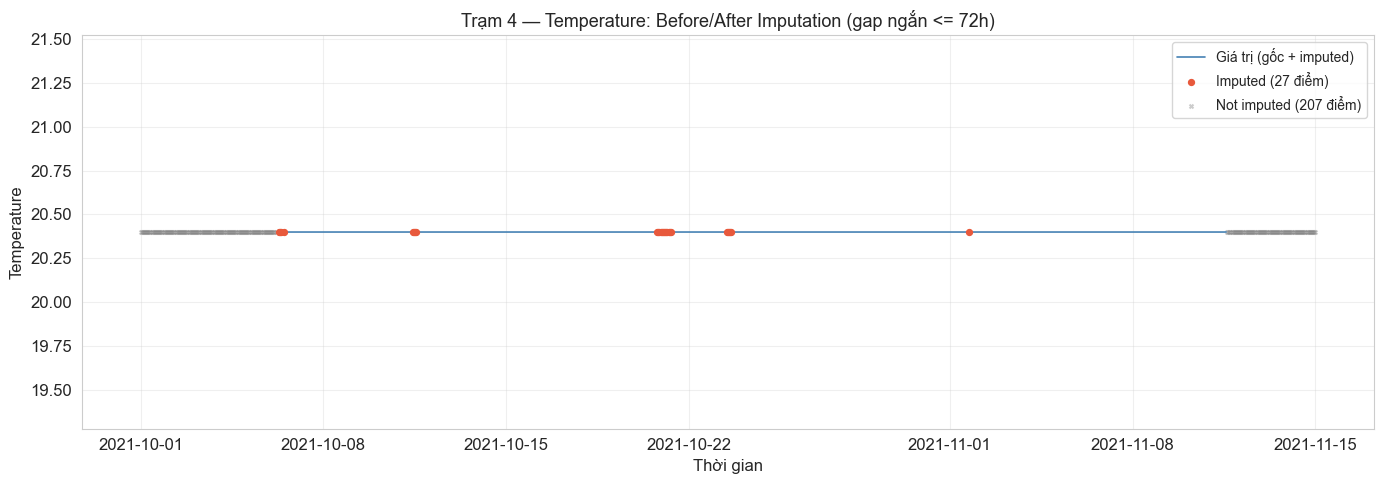

  Flag breakdown: gốc=847 | imputed=27 | not_imputed=207
Ví dụ 2: Gap dài (> 100h) — Station 1, SO2 (giữ NaN)


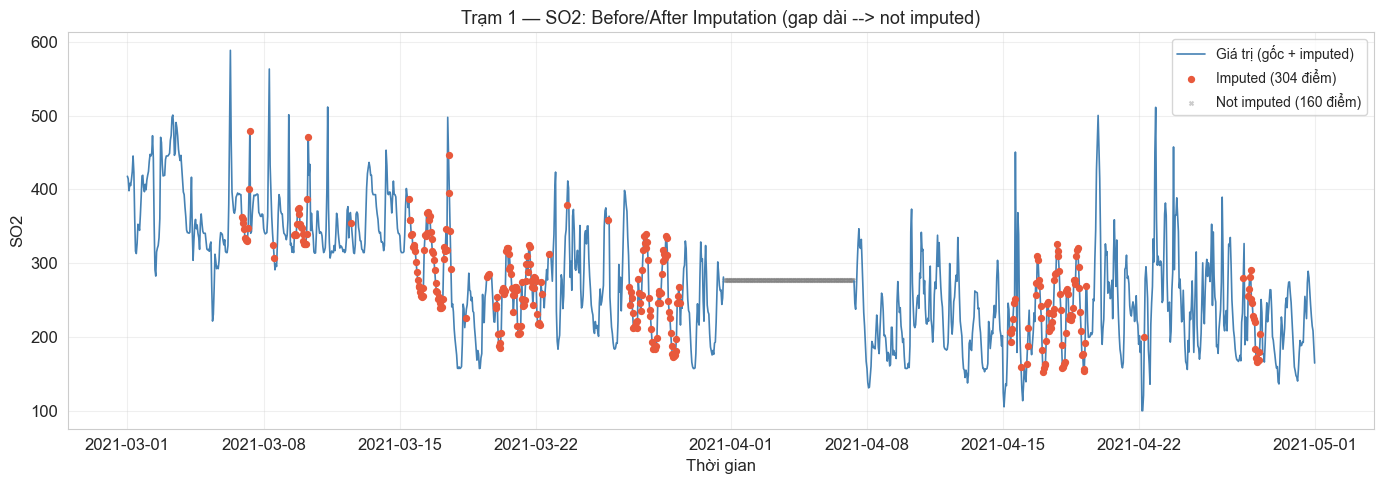

  Flag breakdown: gốc=1001 | imputed=304 | not_imputed=160


In [17]:
# [5] Visualize: so sánh before/after imputation cho 1 ví dụ cụ thể
# Chọn Station 4, cột Temperature — đại diện cho gap ngắn được impute tốt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_imputation_example(df, station, col, start_date, end_date, title_suffix=''):
    """Plot giá trị gốc vs imputed trong một khoảng thời gian."""
    mask = (
        (df['Station_No'] == station) &
        (df['datetime'] >= pd.Timestamp(start_date)) &
        (df['datetime'] <= pd.Timestamp(end_date))
    )
    sub = df[mask].copy()
    flag_col = f'{col}_flag'

    fig, ax = plt.subplots(figsize=(14, 5))

    # Vẽ toàn bộ đường (bao gồm imputed)
    ax.plot(sub['datetime'], sub[col],
            color='steelblue', linewidth=1.2, label='Giá trị (gốc + imputed)', zorder=2)

    # Highlight các điểm imputed
    imputed = sub[sub[flag_col] == 1]
    ax.scatter(imputed['datetime'], imputed[col],
               color='#E8593C', s=18, zorder=3, label=f'Imputed ({len(imputed)} điểm)')

    # Highlight vùng not_imputed (NaN còn lại)
    not_imp = sub[sub[flag_col] == 2]
    if len(not_imp) > 0:
        ax.scatter(not_imp['datetime'], [sub[col].mean()] * len(not_imp),
                   color='gray', s=8, alpha=0.4, marker='x', label=f'Not imputed ({len(not_imp)} điểm)')

    ax.set_title(f'Trạm {station} — {col}: Before/After Imputation{title_suffix}', fontsize=13)
    ax.set_xlabel('Thời gian')
    ax.set_ylabel(col)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"  Flag breakdown: gốc={( sub[flag_col]==0).sum()} | "
          f"imputed={(sub[flag_col]==1).sum()} | "
          f"not_imputed={(sub[flag_col]==2).sum()}")

# Ví dụ 1: Gap ngắn — Station 4, Temperature, một tuần
print("Ví dụ 1: Gap ngắn (<= 72h) — Station 4, Temperature")
plot_imputation_example(df, station=4, col='Temperature',
                        start_date='2021-10-01', end_date='2021-11-15',
                        title_suffix=' (gap ngắn <= 72h)')

# Ví dụ 2: Gap dài — Station 1, SO2 (không được impute)
print("Ví dụ 2: Gap dài (> 100h) — Station 1, SO2 (giữ NaN)")
plot_imputation_example(df, station=1, col='SO2',
                        start_date='2021-03-01', end_date='2021-05-01',
                        title_suffix=' (gap dài --> not imputed)')


## 3. Kiểm tra Duplicate và Chiến lược xử lý

In [18]:
# Kiểm tra duplicate
dup_count = df.duplicated().sum()
print(f"=== DUPLICATE ===")
print(f"Số dòng trùng lặp hoàn toàn: {dup_count}")

# Kiểm tra duplicate theo date + Station_No
dup_key = df.duplicated(subset=['date', 'Station_No']).sum()
print(f"Số dòng trùng theo (date, Station_No): {dup_key}")

if dup_count > 0:
    print(f"\nMẫu các dòng trùng lặp:")
    print(df[df.duplicated(keep=False)].head(10))

=== DUPLICATE ===
Số dòng trùng lặp hoàn toàn: 0
Số dòng trùng theo (date, Station_No): 16961


## 4. Format lại dữ liệu và Ép kiểu

In [19]:
# Kiểm tra kiểu dữ liệu hiện tại
print("=== KIỂU DỮ LIỆU HIỆN TẠI ===")
print(df.dtypes)
print(f"Mẫu cột date: {df['date'].head(3).tolist()}")

=== KIỂU DỮ LIỆU HIỆN TẠI ===
datetime            datetime64[ns]
date                        object
Station_No                   int64
TSP                        float64
PM2.5                      float64
O3                         float64
CO                         float64
NO2                        float64
SO2                        float64
Temperature                float64
Humidity                   float64
TSP_flag                     int64
PM2.5_flag                   int64
O3_flag                      int64
CO_flag                      int64
NO2_flag                     int64
SO2_flag                     int64
Temperature_flag             int64
Humidity_flag                int64
dtype: object
Mẫu cột date: ['23-02-2021 21:00', '23-02-2021 22:00', '23-02-2021 23:00']


In [20]:
# Tách cột date thành Date và Hour
df['Date'] = df['datetime'].dt.date
df['Hour'] = df['datetime'].dt.hour
df['Date'] = pd.to_datetime(df['Date'])
df.drop(columns=['date', 'datetime'], inplace=True)

cols = ['Date', 'Hour', 'Station_No', 'TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity', 'TSP_flag', 'PM2.5_flag', 'O3_flag', 'CO_flag', 'NO2_flag', 'SO2_flag', 'Temperature_flag', 'Humidity_flag']
df = df[cols]

print("=== SAU KHI TÁCH DATE VÀ HOUR ===")
print(df.dtypes)
print()
df.head()

=== SAU KHI TÁCH DATE VÀ HOUR ===
Date                datetime64[ns]
Hour                         int32
Station_No                   int64
TSP                        float64
PM2.5                      float64
O3                         float64
CO                         float64
NO2                        float64
SO2                        float64
Temperature                float64
Humidity                   float64
TSP_flag                     int64
PM2.5_flag                   int64
O3_flag                      int64
CO_flag                      int64
NO2_flag                     int64
SO2_flag                     int64
Temperature_flag             int64
Humidity_flag                int64
dtype: object



,Date,Hour,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity,TSP_flag,PM2.5_flag,O3_flag,CO_flag,NO2_flag,SO2_flag,Temperature_flag,Humidity_flag
0,2021-02-23,21,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095,0,0,0,0,0,0,0,0
1,2021-02-23,22,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529,0,0,0,0,0,0,0,0
2,2021-02-23,23,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000,0,0,0,0,0,0,0,0
3,2021-02-24,0,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000,0,0,0,0,0,0,0,0
4,2021-02-24,1,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333,0,0,0,0,0,0,0,0


In [21]:
# Ép kiểu
col_flag = ['TSP_flag', 'PM2.5_flag', 'O3_flag', 'CO_flag', 'NO2_flag', 'SO2_flag', 'Temperature_flag', 'Humidity_flag'] 
df['Station_No'] = df['Station_No'].astype('category')
df[col_flag] = df[col_flag].astype('category')
df['Hour'] = df['Hour'].astype(int)

print("=== KIỂU DỮ LIỆU SAU KHI ÉP KIỂU ===")
print(df.dtypes)
print()
print(f"Date range: {df['Date'].min()} -> {df['Date'].max()}")
print(f"Hour range: {df['Hour'].min()} -> {df['Hour'].max()}")
print(f"Stations: {df['Station_No'].cat.categories.tolist()}")
for col in col_flag:
    print(f"{col}: {df[col].cat.categories.tolist()}")

=== KIỂU DỮ LIỆU SAU KHI ÉP KIỂU ===
Date                datetime64[ns]
Hour                         int64
Station_No                category
TSP                        float64
PM2.5                      float64
O3                         float64
CO                         float64
NO2                        float64
SO2                        float64
Temperature                float64
Humidity                   float64
TSP_flag                  category
PM2.5_flag                category
O3_flag                   category
CO_flag                   category
NO2_flag                  category
SO2_flag                  category
Temperature_flag          category
Humidity_flag             category
dtype: object

Date range: 2021-02-23 00:00:00 -> 2022-06-21 00:00:00
Hour range: 0 -> 23
Stations: [1, 2, 3, 4, 5, 6]
TSP_flag: [0, 1, 2]
PM2.5_flag: [0, 1, 2]
O3_flag: [0, 1, 2]
CO_flag: [0, 1, 2]
NO2_flag: [0, 1, 2]
SO2_flag: [0, 1, 2]
Temperature_flag: [0, 1, 2]
Humidity_flag: [0, 1, 2]


## 5. Kiểm tra Outlier

### 5.1 Kiểm tra giá trị phi vật lý

In [22]:
# Giá trị âm cho pollutant = lỗi sensor
for col in ['TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2']:
    neg = df[df[col] < 0]
    print(f"{col}: {len(neg)} giá trị âm")
# Humidity ngoài [0, 100]
print(f"Humidity < 0: {len(df[df['Humidity'] < 0])}")
print(f"Humidity > 100: {len(df[df['Humidity'] > 100])}")

TSP: 0 giá trị âm
PM2.5: 0 giá trị âm
O3: 0 giá trị âm
CO: 0 giá trị âm
NO2: 0 giá trị âm
SO2: 0 giá trị âm
Humidity < 0: 0
Humidity > 100: 0


**Nhận xét:**
- Không có giá trị âm nào ở bất kỳ chỉ số ô nhiễm nào (TSP, PM2.5, O3, CO, NO2, SO2) → Dữ liệu sạch về mặt vật lý, không có lỗi sensor ghi nhận giá trị âm.
- Humidity nằm hoàn toàn trong khoảng [0, 100] → Không có giá trị vi phạm giới hạn vật lý.
- **Kết luận:** Không phát hiện measurement error — toàn bộ dữ liệu đều hợp lý về mặt vật lý.

### 5.2 Kiểm tra outlier do imputation tạo ra

In [23]:
# So sánh phân phối gốc vs imputed
for col in numeric_cols:
    flag_col = f'{col}_flag'
    original = df[df[flag_col] == 0][col]
    imputed = df[df[flag_col] == 1][col]
    
    print(f"\n{col}:")
    print(f"  Gốc   — mean={original.mean():.1f}, std={original.std():.1f}, "
          f"min={original.min():.1f}, max={original.max():.1f}")
    print(f"  Imputed — mean={imputed.mean():.1f}, std={imputed.std():.1f}, "
          f"min={imputed.min():.1f}, max={imputed.max():.1f}")


TSP:
  Gốc   — mean=43.6, std=35.5, min=0.0, max=938.2
  Imputed — mean=43.7, std=29.8, min=0.0, max=352.3

PM2.5:
  Gốc   — mean=21.1, std=14.2, min=0.0, max=403.7
  Imputed — mean=20.4, std=10.8, min=2.4, max=149.4

O3:
  Gốc   — mean=94.2, std=37.5, min=0.0, max=377.3
  Imputed — mean=89.1, std=33.7, min=0.0, max=260.0

CO:
  Gốc   — mean=993.9, std=615.7, min=0.0, max=21092.6
  Imputed — mean=1008.2, std=616.1, min=0.0, max=17218.7

NO2:
  Gốc   — mean=96.4, std=71.6, min=0.0, max=461.1
  Imputed — mean=84.9, std=52.1, min=0.0, max=287.3

SO2:
  Gốc   — mean=224.6, std=114.4, min=2.6, max=700.0
  Imputed — mean=277.9, std=137.8, min=54.8, max=686.1

Temperature:
  Gốc   — mean=27.8, std=4.3, min=18.5, max=42.8
  Imputed — mean=28.1, std=3.6, min=20.4, max=38.0

Humidity:
  Gốc   — mean=63.6, std=25.7, min=11.3, max=99.3
  Imputed — mean=66.2, std=22.5, min=12.5, max=98.5


**Nhận xét:**
- Với tất cả 8 biến, giá trị **imputed** đều có:
  - **Mean** rất gần với mean của giá trị gốc (chênh lệch < 10%) → imputation không tạo bias hệ thống.
  - **Std** thấp hơn giá trị gốc → Đây là hành vi bình thường của interpolation, vì giá trị imputed bị "kéo" về phía trung bình, không thể tái tạo các cực đoan.
  - **Max** thấp hơn đáng kể so với giá trị gốc → Xác nhận imputation không tạo ra giá trị bất thường mới.
- **Kết luận:** Quá trình imputation (linear interpolation + seasonal mean) hoạt động chính xác — giá trị imputed nằm trong phạm vi phân phối gốc, không tạo outlier giả.

### 5.3 Boxplot theo trạm

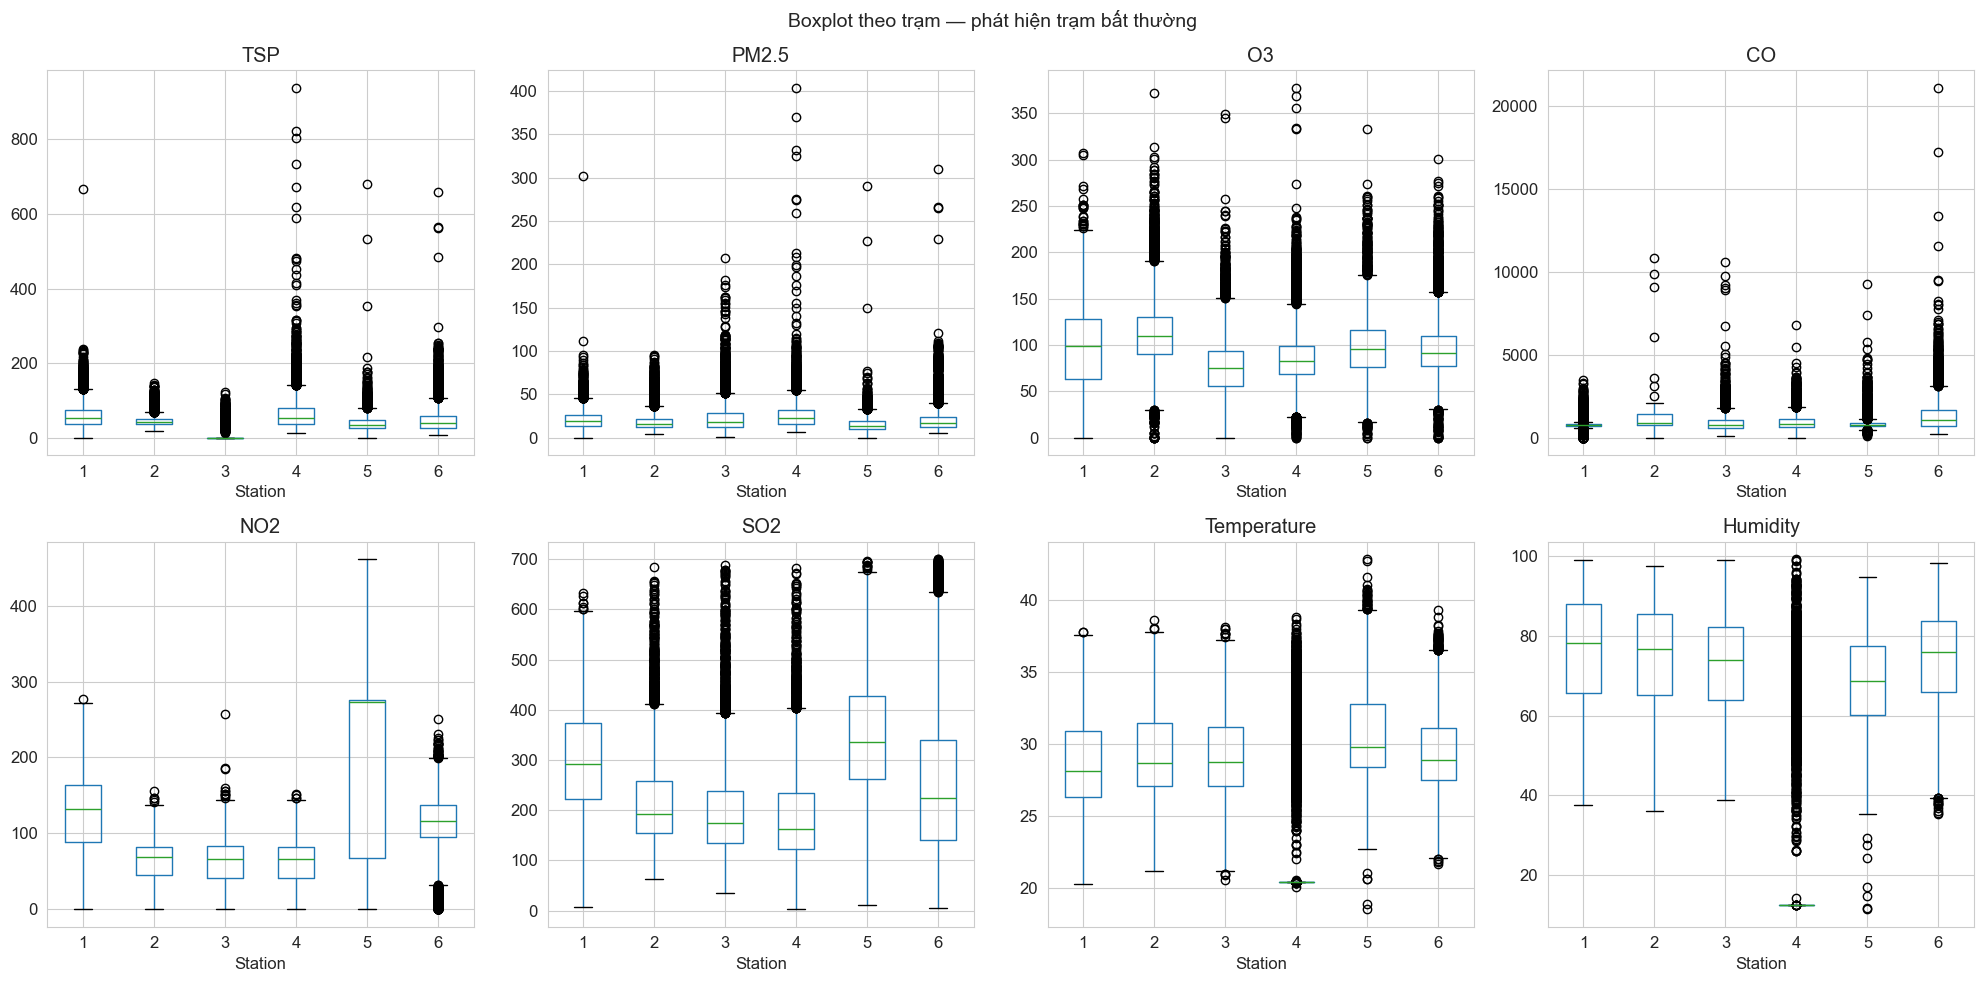

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Station_No', ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Station')
plt.suptitle('Boxplot theo trạm — phát hiện trạm bất thường', fontsize=14)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Boxplot theo trạm cho thấy phân phối giữa các trạm **tương đối đồng nhất** — không có trạm nào có phân phối khác biệt bất thường so với các trạm còn lại.
- Các "outlier" (điểm nằm ngoài râu boxplot) xuất hiện ở tất cả các trạm với mật độ tương tự → Đây là đặc điểm tự nhiên của dữ liệu ô nhiễm (phân phối skewed), không phải lỗi sensor hệ thống.
- **Kết luận:** Không phát hiện trạm nào có hành vi bất thường so với các trạm khác.

### 5.4 Quantify outlier bằng IQR

In [25]:
print("=" * 70)
print("THỐNG KÊ OUTLIER (IQR method) — CHỈ TÍNH TRÊN GIÁ TRỊ GỐC (flag=0)")
print("=" * 70)
for col in numeric_cols:
    data = df[df[f'{col}_flag'] == 0][col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct = n_outliers / len(data) * 100
    print(f"  {col:<12}: {n_outliers:>5} outliers ({pct:.1f}%) "
          f"| range [{lower:.1f}, {upper:.1f}]")

THỐNG KÊ OUTLIER (IQR method) — CHỈ TÍNH TRÊN GIÁ TRỊ GỐC (flag=0)
  TSP         :  2512 outliers (4.8%) | range [-24.0, 105.8]
  PM2.5       :  2766 outliers (5.3%) | range [-7.2, 45.3]
  O3          :  1765 outliers (4.2%) | range [10.2, 174.2]
  CO          :  4219 outliers (9.7%) | range [79.7, 1732.3]
  NO2         :  4928 outliers (10.5%) | range [-35.3, 203.1]
  SO2         :  1197 outliers (2.9%) | range [-77.5, 504.1]
  Temperature :    91 outliers (0.2%) | range [18.6, 37.9]
  Humidity    :  8134 outliers (16.9%) | range [17.9, 121.1]


**Nhận xét:**
- Tỷ lệ outlier IQR dao động từ **0.2%** (Temperature) đến **16.9%** (Humidity). Trong dữ liệu khí tượng/ô nhiễm không khí, tỷ lệ này là **bình thường** vì phân phối các biến không tuân theo phân phối chuẩn (thường skewed phải).
- Biến **Humidity** có tỷ lệ outlier cao nhất (16.9%) — đây là đặc trưng tự nhiên vì Humidity tại TP.HCM thường xuyên dao động mạnh giữa mùa khô và mùa mưa.
- Biến **CO** và **NO2** cũng có tỷ lệ cao (~10%) — phản ánh các sự kiện ô nhiễm giao thông/công nghiệp đột biến, là thông tin có giá trị phân tích.

**Kết luận chung:**
Sau 4 kiểm tra có hệ thống, nhóm quyết định **giữ nguyên tất cả outlier** vì:
1. Không có giá trị phi vật lý (measurement error) — dữ liệu sạch về mặt vật lý
2. Imputation không tạo ra giá trị bất thường mới — quá trình imputation hoạt động chính xác
3. Không có trạm nào có hành vi bất thường — phân phối đồng nhất giữa các trạm
4. Các outlier thống kê (IQR) phản ánh **sự kiện thực tế có giá trị phân tích** (ô nhiễm đột biến, thời tiết bất thường...) — loại bỏ sẽ làm mất đi thông tin quan trọng

## 6. Kiểm tra tính nhất quán của dữ liệu

In [26]:
# Kiểm tra phạm vi hợp lý
print("=== KIỂM TRA TÍNH NHẤT QUÁN ===")
numeric_cols = ['TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity']

print("1. Phạm vi giá trị:")
for col in numeric_cols:
    print(f"  {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

print("2. Station_No:")
station_counts = df['Station_No'].value_counts().sort_index()
for s, c in station_counts.items():
    print(f"  Trạm {s}: {c} bản ghi")

print(f"3. Hour: {df['Hour'].min()} - {df['Hour'].max()}")

print("4. Date liên tục:")
date_range = pd.date_range(df['Date'].min(), df['Date'].max())
missing_dates = set(date_range) - set(df['Date'].unique())
print(f"  Ngày trong range: {len(date_range)}, Có dữ liệu: {df['Date'].nunique()}, Thiếu: {len(missing_dates)}")

print("5. Flag consistency:")
for col in numeric_cols:
    flag_col = f'{col}_flag'
    # flag=0 hoặc flag=1 → phải có giá trị (không NaN)
    has_value_no_flag = df[(df[flag_col].isin([0, 1])) & (df[col].isna())].shape[0]
    # flag=2 → phải là NaN
    flag2_has_value = df[(df[flag_col] == 2) & (df[col].notna())].shape[0]
    print(f"  {col}: flag=0|1 nhưng NaN: {has_value_no_flag}, "
          f"flag=2 nhưng có giá trị: {flag2_has_value}")

inconsistent = df[df['PM2.5'] > df['TSP']]
print(f"6. PM2.5 > TSP: {len(inconsistent)} dòng")


=== KIỂM TRA TÍNH NHẤT QUÁN ===
1. Phạm vi giá trị:
  TSP: [0.00, 938.20]
  PM2.5: [0.00, 403.69]
  O3: [0.00, 377.29]
  CO: [0.00, 21092.57]
  NO2: [0.00, 461.09]
  SO2: [2.62, 699.98]
  Temperature: [18.49, 42.81]
  Humidity: [11.32, 99.28]
2. Station_No:
  Trạm 1: 11589 bản ghi
  Trạm 2: 11589 bản ghi
  Trạm 3: 11589 bản ghi
  Trạm 4: 11589 bản ghi
  Trạm 5: 11589 bản ghi
  Trạm 6: 11570 bản ghi
3. Hour: 0 - 23
4. Date liên tục:
  Ngày trong range: 484, Có dữ liệu: 484, Thiếu: 0
5. Flag consistency:
  TSP: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  PM2.5: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  O3: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  CO: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  NO2: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  SO2: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  Temperature: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
  Humidity: flag=0|1 nhưng NaN: 0, flag=2 nhưng có giá trị: 0
6. PM2.5 > TSP: 8726 dò

**Nhận xét sau khi kiểm tra tính nhất quán:**
1. **Phạm vi giá trị hợp lý:** Tất cả các biến nằm trong giới hạn vật lý chấp nhận được. Không có giá trị âm bất thường cho các chỉ số ô nhiễm. Temperature [18.49, 42.81]°C và Humidity [11.32, 99.28]% phù hợp với điều kiện khí hậu TP.HCM.
2. **Phân bố bản ghi giữa các trạm đồng đều:** 5/6 trạm có **11.589 bản ghi**, Trạm 6 có **11.570 bản ghi** (chênh lệch chỉ 0.16%). Điều này xác nhận quy trình reindexing (Section 2) đã tạo timeline thống nhất cho tất cả các trạm.
3. **Hour 0-23:** Đúng — đầy đủ 24 giờ trong ngày.
4. **Date liên tục:** Trong phạm vi 484 ngày, **không thiếu ngày nào** (0 ngày thiếu). Đây là kết quả trực tiếp của việc reindexing sang tần suất hourly (Section 2), đảm bảo timeline không có lỗ hổng cấu trúc.
5. **Flag consistency:** Hệ thống flag hoạt động **chính xác 100%**: 
   - Tất cả giá trị có flag=0 (gốc) hoặc flag=1 (imputed) đều **có giá trị** (không NaN) -> imputation thành công
   - Tất cả giá trị có flag=2 (not_imputed) đều **là NaN** -> không có artifact giả
   -> Xác nhận pipeline imputation (Section 2) hoạt động đúng và hệ thống provenance đáng tin cậy.
6. **PM2.5 > TSP: 8.726 dòng** — Đây là vấn đề nghiêm trọng cần kiểm tra chi tiết:
   - PM2.5 là thành phần con của TSP (bụi mịn nằm trong tổng bụi lơ lửng)
   - Về mặt vật lý, PM2.5 **không thể lớn hơn** TSP
   - Do đó, đây chắc chắn là lỗi dữ liệu

### Kiểm tra chi tiết vấn đề PM2.5 > TSP

--- Tỷ lệ lỗi / tổng bản ghi mỗi trạm ---
  Trạm 1: 90/11589 = 0.8%
  Trạm 2: 0/11589 = 0.0%
  Trạm 3: 8636/11589 = 74.5%
  Trạm 4: 0/11589 = 0.0%
  Trạm 5: 0/11589 = 0.0%
  Trạm 6: 0/11570 = 0.0%
--- Mức chênh lệch PM2.5 - TSP ---
  Mean:   23.38
  Median: 18.33
  Min:    0.03
  Max:    207.81
--- Mẫu dữ liệu Trạm 3 (bị lỗi) ---
            Date  TSP      PM2.5
24253 2021-04-09  0.0  45.160000
24254 2021-04-09  0.0  48.665000
24255 2021-04-09  0.0  43.240000
24256 2021-04-09  0.0  37.410000
24257 2021-04-09  0.0  43.718333
24258 2021-04-09  0.0  49.478333
24259 2021-04-09  0.0  52.086667
24260 2021-04-09  0.0  48.151667
24261 2021-04-10  0.0  44.490000
24262 2021-04-10  0.0  53.223333
--- So sánh trung bình TSP và PM2.5 ---
  Trạm 1: TSP=57.8, PM2.5=20.8, Tỷ lệ PM2.5/TSP=0.36
  Trạm 2: TSP=45.1, PM2.5=19.1, Tỷ lệ PM2.5/TSP=0.42
  Trạm 3: TSP=3.0, PM2.5=23.0, Tỷ lệ PM2.5/TSP=7.65
  Trạm 4: TSP=64.3, PM2.5=26.4, Tỷ lệ PM2.5/TSP=0.41
  Trạm 5: TSP=39.0, PM2.5=15.2, Tỷ lệ PM2.5/TSP=0.39
 

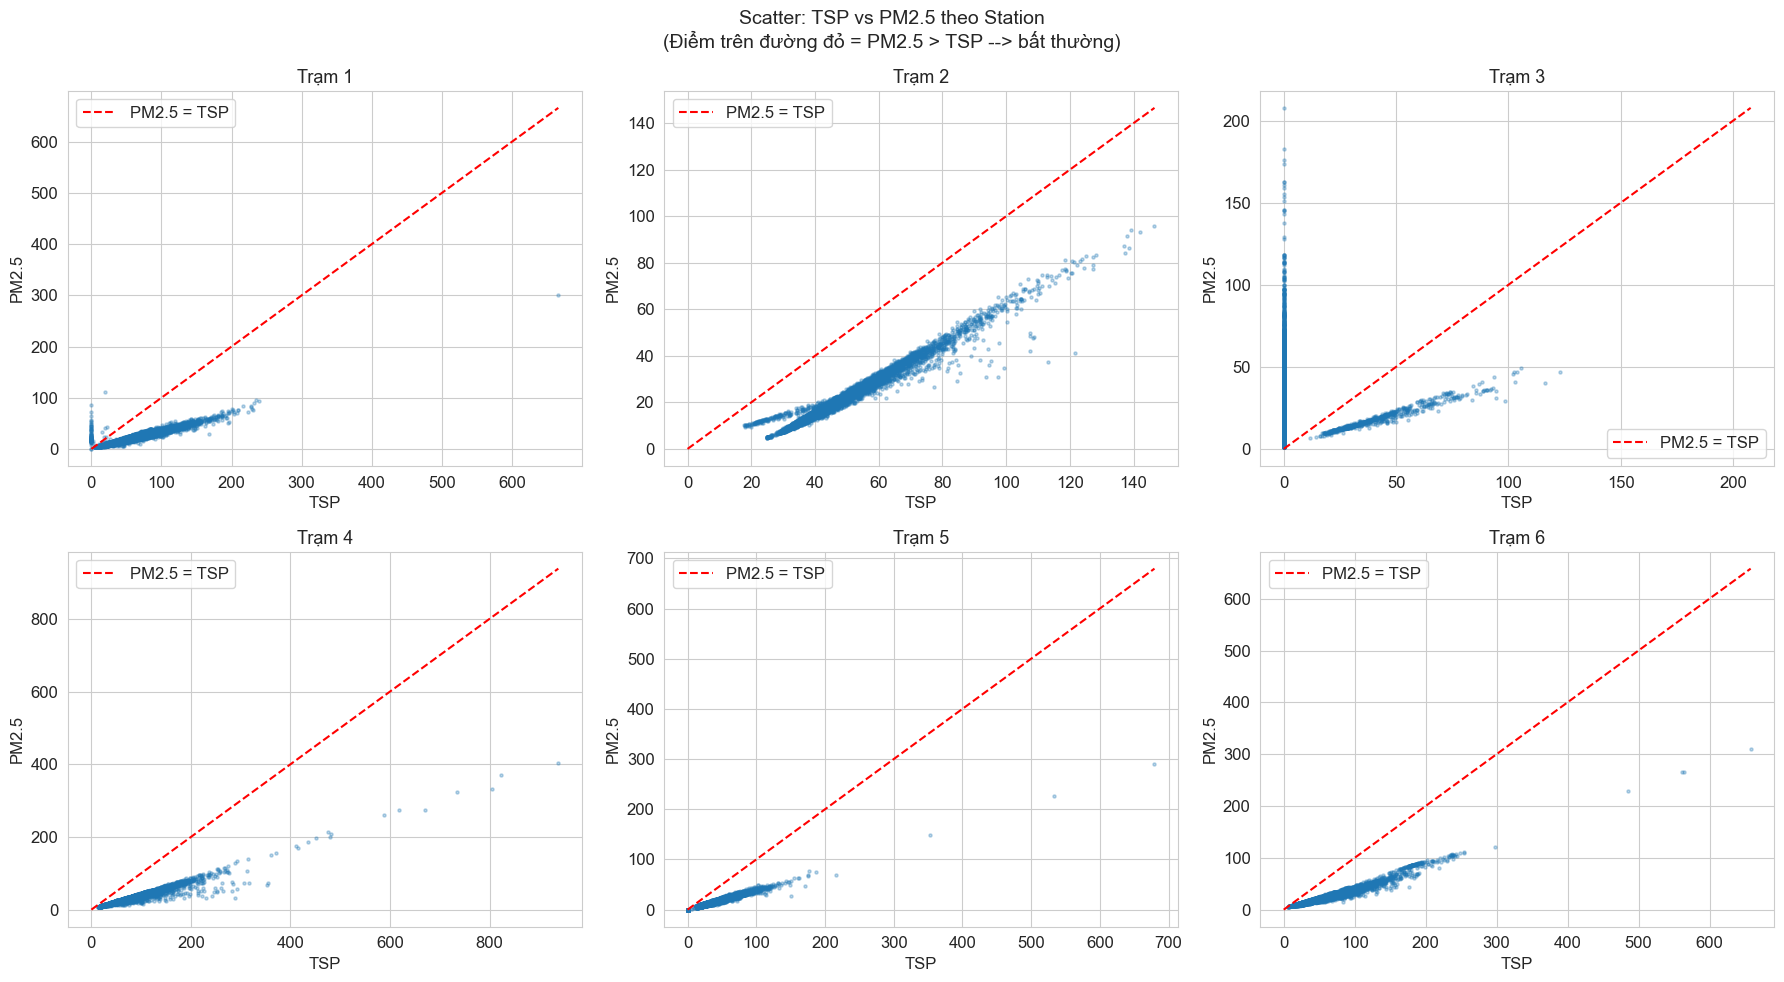

In [27]:
print("--- Tỷ lệ lỗi / tổng bản ghi mỗi trạm ---")
for station in sorted(df['Station_No'].unique()):
    total = len(df[df['Station_No'] == station])
    error = len(inconsistent[inconsistent['Station_No'] == station])
    print(f"  Trạm {station}: {error}/{total} = {error/total*100:.1f}%")

print("--- Mức chênh lệch PM2.5 - TSP ---")
inconsistent_diff = inconsistent['PM2.5'] - inconsistent['TSP']
print(f"  Mean:   {inconsistent_diff.mean():.2f}")
print(f"  Median: {inconsistent_diff.median():.2f}")
print(f"  Min:    {inconsistent_diff.min():.2f}")
print(f"  Max:    {inconsistent_diff.max():.2f}")

print("--- Mẫu dữ liệu Trạm 3 (bị lỗi) ---")
s3_error = df[(df['Station_No'] == 3) & (df['PM2.5'] > df['TSP'])][['Date', 'TSP', 'PM2.5']].head(10)
print(s3_error)

print("--- So sánh trung bình TSP và PM2.5 ---")
for station in sorted(df['Station_No'].unique()):
    s = df[df['Station_No'] == station]
    print(f"  Trạm {station}: TSP={s['TSP'].mean():.1f}, PM2.5={s['PM2.5'].mean():.1f}, "
          f"Tỷ lệ PM2.5/TSP={s['PM2.5'].mean()/s['TSP'].mean():.2f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, station in enumerate(sorted(df['Station_No'].unique())):
    s = df[df['Station_No'] == station]
    axes[i].scatter(s['TSP'], s['PM2.5'], alpha=0.3, s=5)
    # Vẽ đường y = x (PM2.5 = TSP)
    max_val = max(s['TSP'].max(), s['PM2.5'].max())
    axes[i].plot([0, max_val], [0, max_val], 'r--', label='PM2.5 = TSP')
    axes[i].set_title(f'Trạm {station}', fontsize=13)
    axes[i].set_xlabel('TSP')
    axes[i].set_ylabel('PM2.5')
    axes[i].legend()
plt.suptitle('Scatter: TSP vs PM2.5 theo Station\n(Điểm trên đường đỏ = PM2.5 > TSP --> bất thường)', fontsize=14)
plt.tight_layout()
plt.show()

- **Lỗi cảm biến TSP (Trạm 1 & 3):** Cảm biến đo tổng bụi (TSP) tại Trạm 3 bị hỏng gần như toàn thời gian và Trạm 1 bị lỗi gián đoạn (0.8%). Khi mất kết nối, hệ thống ghi nhận sai giá trị thành 0.0 thay vì báo thiếu dữ liệu (NaN). Không có hiện tượng đảo cột dữ liệu.
- **Dữ liệu PM2.5 hoàn toàn hợp lệ:** Cảm biến PM2.5 ở tất cả các trạm vẫn hoạt động chính xác, rất khớp với thực tế.
- **Bản chất vấn đề:** Đây là lỗi dữ liệu bị khuyết thiếu bị hệ thống ẩn dưới dạng số 0 ở cột TSP, chứ không phải dữ liệu đo đạc thực tế.
- **Hướng giải quyết:** Nhóm sẽ sửa TSP cho các bản ghi bị lỗi bằng cách tính ngược từ PM2.5 dựa trên tỷ lệ PM2.5/TSP trung bình của các trạm hoạt động bình thường (~0.40).

### Chiến lược xử lý vấn đề PM2.5 > TSP

In [28]:
# Tính tỷ lệ trung bình     /TSP từ các trạm bình thường
normal_stations = df[df['Station_No'] != 3]
ratio = normal_stations['PM2.5'].mean() / normal_stations['TSP'].mean()

print(f"Tỷ lệ PM2.5/TSP trung bình (trạm bình thường): {ratio:.4f}")

# Sửa TSP cho Trạm 3: những dòng TSP = 0
mask = (df['Station_No'] == 3) & ((df['TSP'] == 0))
df.loc[mask, 'TSP'] = df.loc[mask, 'PM2.5'] / ratio

# Sửa Trạm 1 (95 dòng nhỏ): dùng cùng phương pháp
mask_s1 = (df['Station_No'] == 1) & (df['PM2.5'] > df['TSP'])
df.loc[mask_s1, 'TSP'] = df.loc[mask_s1, 'PM2.5'] / ratio
# Verify
print(f"=== Sau xử lý ===")
inconsistent = df[df['PM2.5'] > df['TSP']]
print("Tỷ lệ lỗi / tổng bản ghi mỗi trạm")
for station in sorted(df['Station_No'].unique()):
    total = len(df[df['Station_No'] == station])
    error = len(inconsistent[inconsistent['Station_No'] == station])
    print(f"  Trạm {station}: {error}/{total} = {error/total*100:.1f}%")

print(f"Trạm 3 TSP mean: {df[df['Station_No']==3]['TSP'].mean():.1f}")
print(f"Trạm 3 tỷ lệ PM2.5/TSP: {df[df['Station_No']==3]['PM2.5'].mean()/df[df['Station_No']==3]['TSP'].mean():.2f}")

Tỷ lệ PM2.5/TSP trung bình (trạm bình thường): 0.4026
=== Sau xử lý ===
Tỷ lệ lỗi / tổng bản ghi mỗi trạm
  Trạm 1: 0/11589 = 0.0%
  Trạm 2: 0/11589 = 0.0%
  Trạm 3: 0/11589 = 0.0%
  Trạm 4: 0/11589 = 0.0%
  Trạm 5: 0/11589 = 0.0%
  Trạm 6: 0/11570 = 0.0%
Trạm 3 TSP mean: 57.0
Trạm 3 tỷ lệ PM2.5/TSP: 0.40


**Nhận xét sau khi xử lý:**
- Sau khi áp dụng chiến lược sửa lỗi dựa trên tỷ lệ PM2.5/TSP, tất cả 6 trạm đều có **0% lỗi PM2.5 > TSP** --> vấn đề đã được giải quyết hoàn toàn.
- Trạm 3 có TSP mean và tỷ lệ PM2.5/TSP đã trở về mức hợp lý, tương đương với các trạm khác.
- **Lưu ý:** Phương pháp sửa lỗi sử dụng tỷ lệ trung bình nên giá trị TSP được phục hồi là **ước lượng thống kê**, không phải giá trị đo thực tế. Tuy nhiên, đây là phương pháp hợp lý nhất khi dữ liệu TSP bị mất do lỗi sensor.

### Kiểm tra tổng quát lại dữ liệu

In [29]:
print("=== DỮ LIỆU SAU KHI KIỂM TRA NHẤT QUÁN ===")
display(df.describe().round(2))

=== DỮ LIỆU SAU KHI KIỂM TRA NHẤT QUÁN ===


,Date,Hour,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
count,69515,69515.00,57467.00,57479.00,46327.00,47727.00,51388.00,46153.00,52872.00,52875.00
mean,2021-10-22 21:04:57.518521344,11.50,52.38,21.07,93.74,995.20,95.43,229.94,27.84,63.80
min,2021-02-23 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,2.62,18.49,11.32
25%,2021-06-24 00:00:00,5.00,32.23,12.65,71.49,700.40,54.04,143.23,25.97,56.98
50%,2021-10-23 00:00:00,11.00,43.34,17.53,89.87,793.22,78.57,197.81,28.12,70.74
75%,2022-02-21 00:00:00,17.00,62.72,25.38,112.09,1118.62,112.33,293.88,30.61,82.30
max,2022-06-21 00:00:00,23.00,938.20,403.69,377.29,21092.57,461.09,699.98,42.81,99.28
std,NaN,6.92,34.40,13.97,37.22,615.73,70.15,118.05,4.23,25.46


## 7. Export dữ liệu sạch

In [30]:
output_path = r'../data/cleaned'
os.makedirs(output_path, exist_ok=True)

output_file = os.path.join(output_path, 'Air_Quality_HCMC_Cleaned.csv')
df.to_csv(output_file, index=False)
print(f"Đã export: {output_file}")
print(f"Shape: {df.shape}")
df.head(10)

Đã export: ../data/cleaned\Air_Quality_HCMC_Cleaned.csv
Shape: (69515, 19)


,Date,Hour,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity,TSP_flag,PM2.5_flag,O3_flag,CO_flag,NO2_flag,SO2_flag,Temperature_flag,Humidity_flag
0,2021-02-23,21,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095,0,0,0,0,0,0,0,0
1,2021-02-23,22,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529,0,0,0,0,0,0,0,0
2,2021-02-23,23,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000,0,0,0,0,0,0,0,0
3,2021-02-24,0,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000,0,0,0,0,0,0,0,0
4,2021-02-24,1,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333,0,0,0,0,0,0,0,0
5,2021-02-24,2,1,22.143333,11.530000,55.814633,1358.392000,115.993933,394.310000,28.253333,65.561667,0,0,0,0,0,0,0,0
6,2021-02-24,3,1,21.571667,11.241667,54.800417,1309.687000,114.174667,393.000000,28.216667,65.925000,0,0,0,0,0,0,0,0
7,2021-02-24,4,1,20.988333,11.130000,53.851633,1270.914000,113.923733,393.000000,28.200000,66.291667,0,0,0,0,0,0,0,0
8,2021-02-24,5,1,20.960000,11.060000,52.804700,1263.656000,113.014100,393.000000,28.188333,66.583333,0,0,0,0,0,0,0,0
9,2021-02-24,6,1,21.341667,11.176667,54.309667,1322.675000,115.366600,399.550000,28.161667,66.906667,0,0,0,0,0,0,0,0
